# Егоров Г.О. Кластеризация физической активности

 Описание задания:

 В современном мире существуют множество различных устройств (фитнес-браслетов, камер, датчиков и т.д.), которые собирают данные об активности пользователя. Эти сведения могут быть использованы, например, для отслеживания состояния здоровья человека и определение находится ли он сейчас в безопасности, что он делает и так далее.

Данные, собранные с носимых устройств, которые отслеживают физическую активность пользователей, используются во множестве коммерческих приложений, включая здравоохранение, фитнес-тренировки, навигационную систему и так далее.

В данной задаче вам предлагается, используя информацию, собранную с помощью трех Инерциальных измерительных модуля (IMU) и пульсометра.

Дано:

**Датасет содержит по 54 столбца на строку, столбцы содержат следующие данные:**
- 1 временная метка (с)
- 2 частота сердечных сокращений (уд/мин)
- 3-19 данные с датчиков на руке
- 20-36 данные с датчиков на груди
- 37-53 данные с датчиков на лодыжке

**Сенсорные данные IMU содержат следующие столбцы:**
- 1 температура (°C)
- 2-4 Данные 3D-ускорения (мс-2), масштаб: ±16g, разрешение: 13 бит
- 5-7 Данные 3D-ускорения (мс-2), масштаб: ±6g, разрешение: 13 бит*
- 8-10 данных 3D-гироскопа (рад/с)
- 11-13 Данные 3D-магнитометра (мкТл)

### Загружаем данные

### 1. Сделаем необходимые импорты. Пропишем константы, необходимые в дальнейшем

In [97]:
# =====================================================================
# 0. Импорт библиотек и константы
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy.signal import welch          # <-- ВАЖНО: добавлен импорт welch
from collections import defaultdict

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from pandas.plotting import scatter_matrix
# Для HDBSCAN (если не установлен – pip install hdbscan)
import hdbscan

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
WINDOW_SEC = 10.0      # длина окна
STEP_SEC = 5.0
MIN_SAMPLES_PER_WINDOW = 20

In [88]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/datasets/Physical_Activity_Monitoring_unlabeled.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
df

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,...,-0.025606,0.030239,-14.54470,27.3336,-5.766200,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,...,-0.670163,1.786200,-32.82570,-15.7719,-1.313950,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,...,-0.009741,-0.006579,-18.81710,16.3089,25.292800,0.139776,0.676586,0.393796,0.606316,8
3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,...,-0.163470,-3.495570,-26.74180,34.3566,21.327400,0.416303,0.783387,0.306464,0.345075,2
4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,...,-0.028172,-0.003737,-17.77980,-3.9981,10.995000,0.171133,-0.748343,0.252988,-0.588807,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534596,3479.53,33.8750,-9.084250,4.70122,2.890170,-9.689610,6.78077,3.975430,-0.157406,0.774189,...,0.424520,-0.856836,-25.00990,-23.5557,23.615300,0.318171,-0.701921,0.555778,-0.311745,5
534597,2448.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.767710,-3.050980,-35.70240,31.8018,16.421800,0.435887,0.660643,0.371665,0.485200,5
534598,2479.84,34.6875,-6.367550,2.32131,2.207640,-6.362460,2.33049,2.607610,0.206349,-0.359415,...,-0.034144,-0.402013,-49.69220,20.6039,-0.917908,0.561652,0.297957,0.756767,0.151899,5
534599,3437.82,28.0625,5.461940,10.43640,-9.073300,8.348860,5.76518,-6.143210,3.543910,2.757300,...,0.352062,-5.577750,-34.15510,-11.0786,39.737500,0.062163,-0.798705,-0.056668,-0.595815,6


Созраним исхолный размер в переменную, для дальнейшей проверки после обработки

In [91]:
ORIGINAL_ROWS = len(df)
print('Исходный размер:', df.shape)

Исходный размер: (534601, 53)


In [ ]:
# x y z -> v = sqrt(x^2 + y^2 + z^2)
# масштабирование
# PCA - метод главных компонент
# Удалили признаки, заполнение признаков

# KNNImputer

Посмотрим содержимое датасета

In [92]:
df.columns

Index(['timestamp', 'handTemperature', 'handAcc16_1', 'handAcc16_2',
       'handAcc16_3', 'handAcc6_1', 'handAcc6_2', 'handAcc6_3', 'handGyro1',
       'handGyro2', 'handGyro3', 'handMagne1', 'handMagne2', 'handMagne3',
       'handOrientation1', 'handOrientation2', 'handOrientation3',
       'handOrientation4', 'chestTemperature', 'chestAcc16_1', 'chestAcc16_2',
       'chestAcc16_3', 'chestAcc6_1', 'chestAcc6_2', 'chestAcc6_3',
       'chestGyro1', 'chestGyro2', 'chestGyro3', 'chestMagne1', 'chestMagne2',
       'chestMagne3', 'chestOrientation1', 'chestOrientation2',
       'chestOrientation3', 'chestOrientation4', 'ankleTemperature',
       'ankleAcc16_1', 'ankleAcc16_2', 'ankleAcc16_3', 'ankleAcc6_1',
       'ankleAcc6_2', 'ankleAcc6_3', 'ankleGyro1', 'ankleGyro2', 'ankleGyro3',
       'ankleMagne1', 'ankleMagne2', 'ankleMagne3', 'ankleOrientation1',
       'ankleOrientation2', 'ankleOrientation3', 'ankleOrientation4',
       'subject_id'],
      dtype='object')

In [93]:
df.head(10)

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,...,-0.025606,0.030239,-14.5447,27.33360,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,...,-0.670163,1.786200,-32.8257,-15.77190,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,...,-0.009741,-0.006579,-18.8171,16.30890,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,...,-0.163470,-3.495570,-26.7418,34.35660,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,...,-0.028172,-0.003737,-17.7798,-3.99810,10.99500,0.171133,-0.748343,0.252988,-0.588807,6
5,2407.75,32.2500,-11.248600,4.70549,1.472190,-10.437400,4.45819,1.595360,1.376280,1.629110,...,0.395789,-0.734158,-37.2300,-17.66060,25.97660,0.081638,-0.564666,-0.465628,-0.676519,6
6,288.18,33.8125,-9.003480,3.48025,2.202730,-8.781060,3.45025,2.426420,0.291490,-0.142762,...,0.009919,0.016218,-61.3576,-33.90920,-13.77570,0.542814,-0.366369,0.626705,-0.422336,2
7,2926.96,31.8125,-1.183270,4.29157,6.435280,-1.338840,5.22864,7.488770,-0.100648,0.209315,...,0.057945,0.394188,-63.8337,14.46170,14.48690,1.000000,0.000000,0.000000,0.000000,1
8,738.33,34.5625,-8.875780,-5.29485,1.156600,-8.606980,-5.44707,1.569890,-0.276623,-0.353238,...,0.016960,-0.009354,-37.2116,-2.25659,10.92460,0.146531,-0.810946,0.130713,-0.551189,8
9,2934.54,31.7500,-6.033980,6.36204,8.818830,-2.939410,6.99344,8.966410,0.124129,-0.301420,...,0.179439,-1.369650,-60.5519,-36.30930,-1.18247,1.000000,0.000000,0.000000,0.000000,1


### 2. EDA

Посмотрим на пропущенные данные

In [94]:
missing_values = df.isnull().sum()

# Фильтруем только столбцы с пропусками
missing_data = missing_values[missing_values > 0].to_frame(name="Missing Count")
missing_data["Missing Percentage"] = (missing_data["Missing Count"] / ORIGINAL_ROWS) * 100

missing_data

,Missing Count,Missing Percentage
handTemperature,4041,0.755891
handAcc16_1,4041,0.755891
handAcc16_2,4041,0.755891
handAcc16_3,4041,0.755891
handAcc6_1,4041,0.755891
handAcc6_2,4041,0.755891
handAcc6_3,4041,0.755891
handGyro1,4041,0.755891
handGyro2,4041,0.755891
handGyro3,4041,0.755891


In [95]:
missing_data.shape

(51, 2)

Построим корреляционную тепловую карту признаков

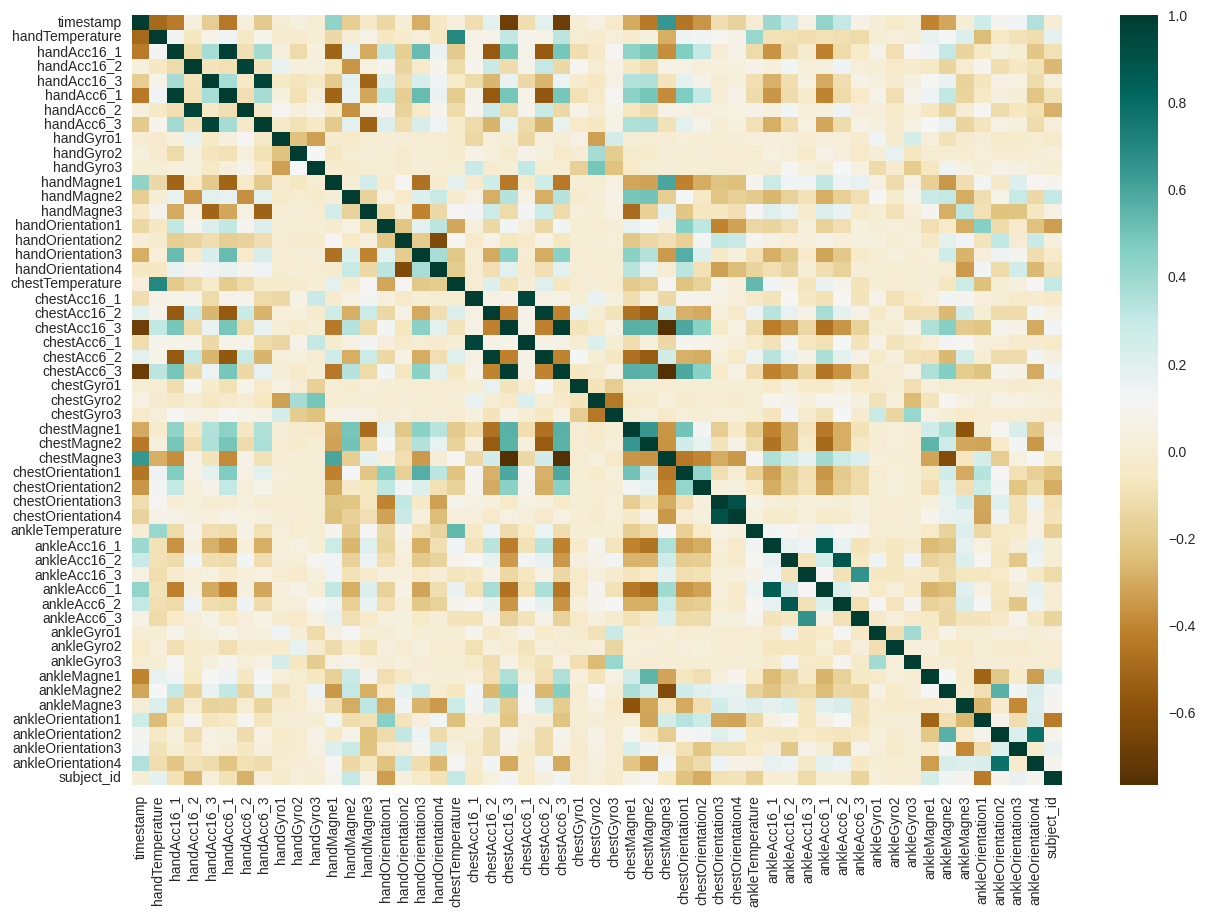

In [98]:
df_corr = df.corr()

f, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(df_corr, mask=np.zeros_like(df_corr, dtype=np.bool), cmap = "BrBG", ax=ax)
plt.show()

In [99]:
df_corr

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
timestamp,1.000000,-0.503251,-0.430108,0.037308,-0.185536,-0.440134,0.033043,-0.196541,-0.001776,0.039775,...,-0.037408,-0.001409,-0.406662,-0.308043,0.012547,0.264602,0.092868,0.143476,0.349594,0.012036
handTemperature,-0.503251,1.000000,0.128313,-0.062824,0.070978,0.141391,-0.053342,0.088108,-0.017757,-0.015093,...,0.020970,0.003894,0.169802,0.117623,0.215302,-0.243552,-0.051689,-0.085791,-0.104597,0.184085
handAcc16_1,-0.430108,0.128313,1.000000,-0.119327,0.372003,0.981441,-0.104263,0.379149,0.027879,-0.122974,...,-0.102395,0.099146,0.143615,0.299498,-0.151357,-0.050893,0.039575,0.004017,-0.214779,-0.091061
handAcc16_2,0.037308,-0.062824,-0.119327,1.000000,-0.078163,-0.094160,0.964042,-0.078683,0.170185,0.035166,...,-0.031461,-0.025563,-0.052246,-0.146814,-0.009412,0.090633,-0.110483,-0.061181,-0.088267,-0.259731
handAcc16_3,-0.185536,0.070978,0.372003,-0.078163,1.000000,0.365738,-0.048543,0.972072,-0.049480,-0.076507,...,-0.020548,0.038946,0.114707,0.158749,-0.154496,-0.069973,0.052387,0.040844,-0.116679,0.017130
handAcc6_1,-0.440134,0.141391,0.981441,-0.094160,0.365738,1.000000,-0.097805,0.373731,0.039080,-0.096332,...,-0.099563,0.084905,0.144941,0.304708,-0.147209,-0.055477,0.039540,0.006079,-0.217324,-0.089772
handAcc6_2,0.033043,-0.053342,-0.104263,0.964042,-0.048543,-0.097805,1.000000,-0.045680,0.103628,0.027169,...,-0.032059,0.013515,-0.056243,-0.152469,-0.008423,0.096659,-0.115531,-0.064867,-0.092559,-0.278524
handAcc6_3,-0.196541,0.088108,0.379149,-0.078683,0.972072,0.373731,-0.045680,1.000000,-0.044158,-0.088728,...,-0.019912,0.040654,0.116535,0.165048,-0.150663,-0.075499,0.054005,0.040330,-0.117443,0.024405
handGyro1,-0.001776,-0.017757,0.027879,0.170185,-0.049480,0.039080,0.103628,-0.044158,1.000000,-0.235321,...,-0.025456,0.245427,0.019654,-0.087998,-0.014848,0.010101,-0.035058,-0.024571,-0.010680,-0.029383
handGyro2,0.039775,-0.015093,-0.122974,0.035166,-0.076507,-0.096332,0.027169,-0.088728,-0.235321,1.000000,...,0.166137,-0.063582,-0.011706,-0.008502,-0.012893,0.014029,-0.008282,-0.012088,-0.000472,0.013270


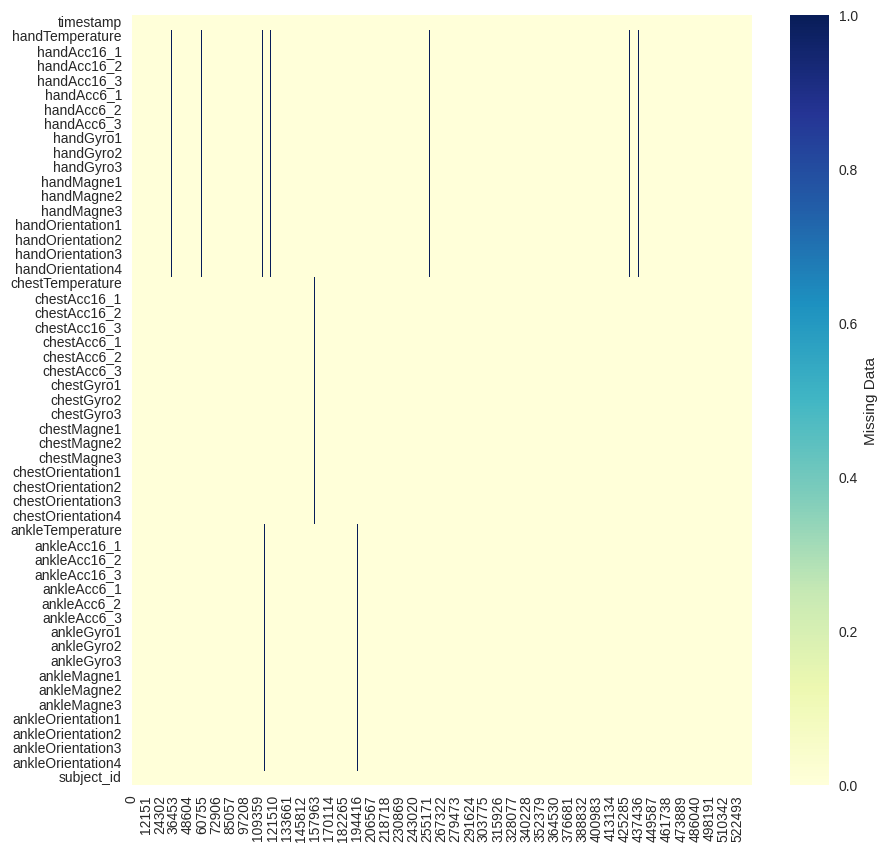

In [100]:
plt.figure(figsize=(10,10))
sns.heatmap(df.isna().transpose(),
            cmap="YlGnBu",
            cbar_kws={'label': 'Missing Data'})
plt.savefig("visualizing_missing_data_with_heatmap_Seaborn_Python.png", dpi=100)

<Axes: >

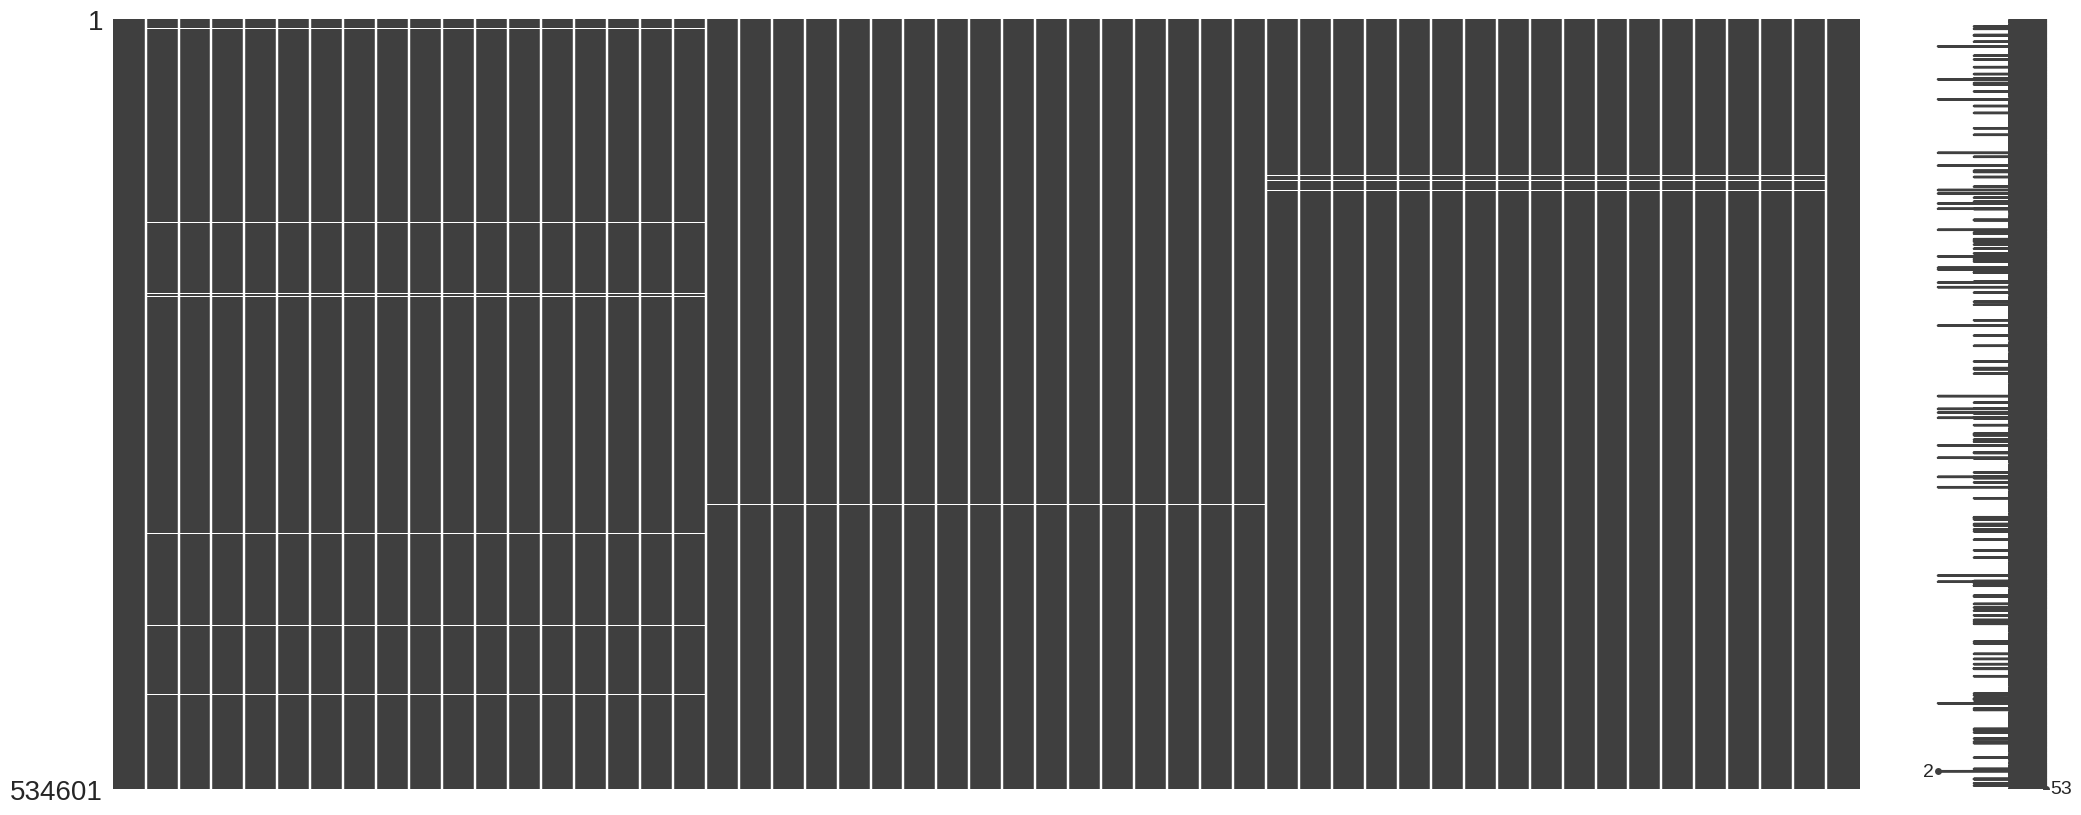

In [101]:
msno.matrix(df)

Данные содержат множество пропущенных значений

Посмотрим распределение записей по субъектам

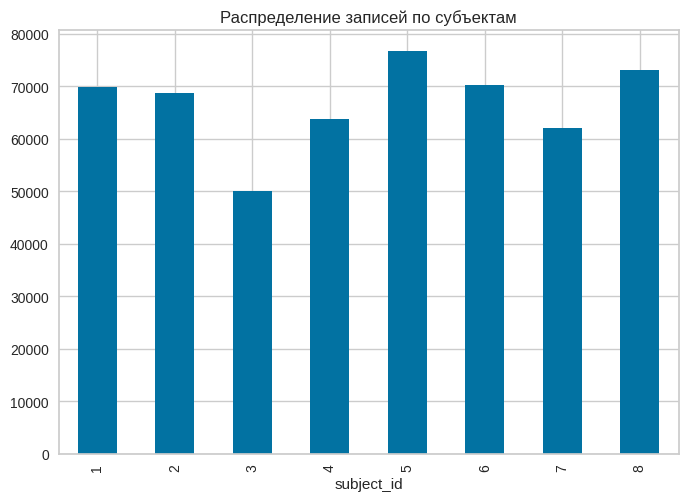

Топ-3 субъекта: [5, 8, 6]


In [102]:
sub_counts = df['subject_id'].value_counts().sort_index()
sub_counts.plot(kind='bar')
plt.title('Распределение записей по субъектам')
plt.show()
print('Топ-3 субъекта:', sub_counts.nlargest(3).index.tolist())

Наибольшее кол-во записей у субъектов - 5,6,8

Посмотрим корреляции магнитуд ускорений (временное дропание пропусков).

Mag = $\sqrt{x^2+y^2+z^2}$


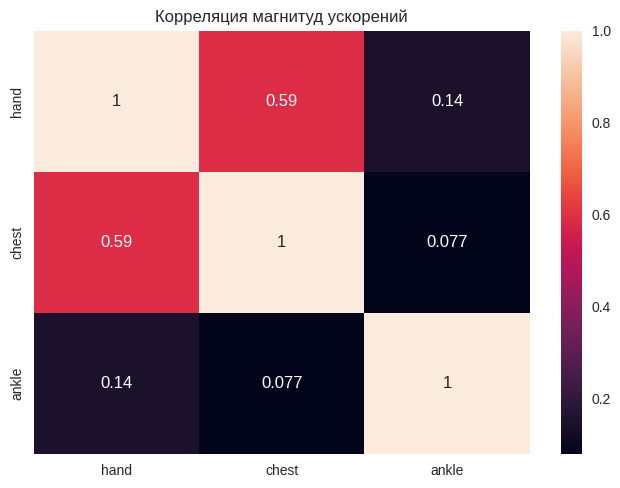

In [103]:
temp = df.dropna(subset=['handAcc16_1','chestAcc16_1','ankleAcc16_1'])
hand_mag = np.sqrt((temp[['handAcc16_1','handAcc16_2','handAcc16_3']]**2).sum(axis=1))
chest_mag = np.sqrt((temp[['chestAcc16_1','chestAcc16_2','chestAcc16_3']]**2).sum(axis=1))
ankle_mag = np.sqrt((temp[['ankleAcc16_1','ankleAcc16_2','ankleAcc16_3']]**2).sum(axis=1))
corr = np.corrcoef([hand_mag, chest_mag, ankle_mag])
sns.heatmap(corr, annot=True, xticklabels=['hand','chest','ankle'], yticklabels=['hand','chest','ankle'])
plt.title('Корреляция магнитуд ускорений')
plt.show()

Все три датчика несут взаимодополняющую информацию, поэтому удалять датчик руки нельзя — мы потеряем важные признаки для разделения активностей.

Корреляции: chest–hand ≈ 0.59, hand–ankle ≈ 0.14, chest–ankle ≈ 0.077. Лодыжка почти независима, что необходимо учитывать при построении признаков.

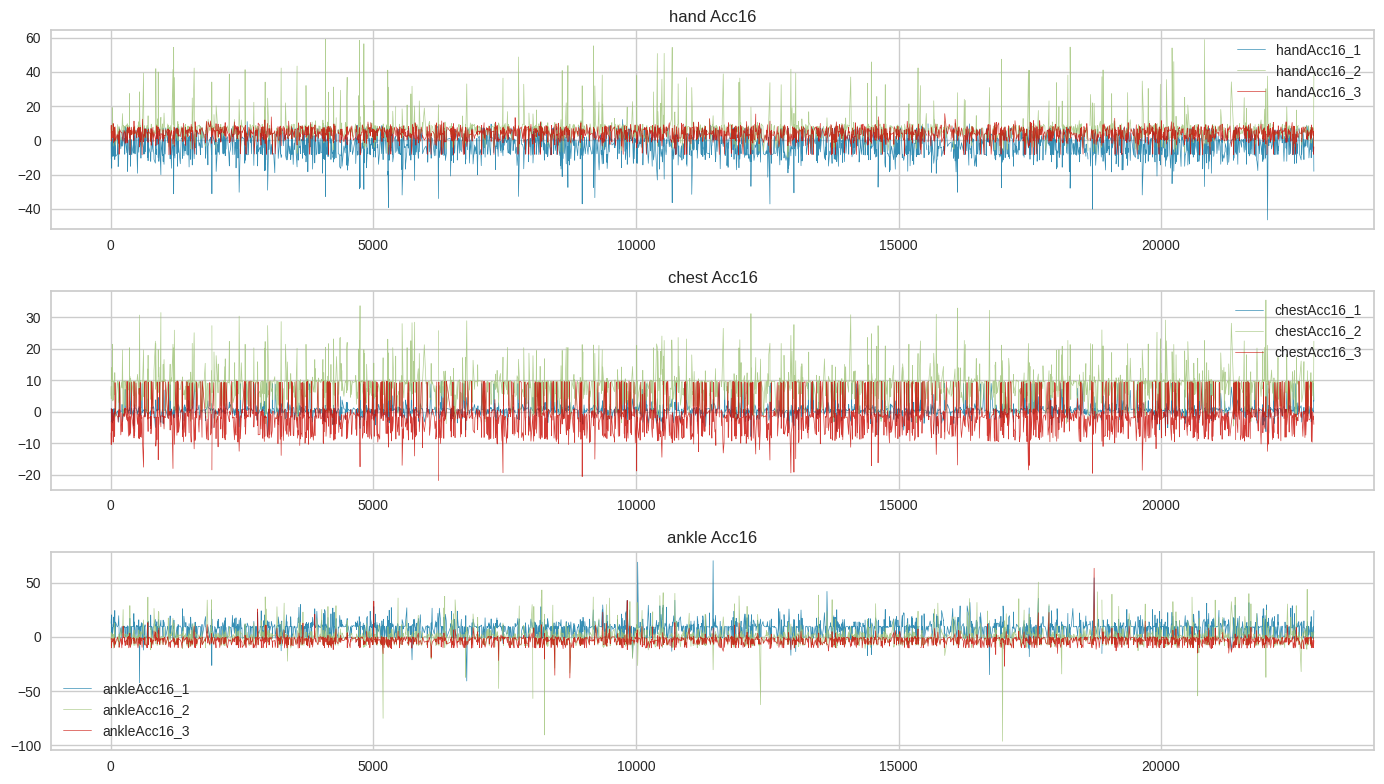

In [104]:
sub1 = df[df['subject_id']==1].head(3000)
fig, axes = plt.subplots(3,1,figsize=(14,8))
for ax, loc in zip(axes, ['hand','chest','ankle']):
    cols = [f'{loc}Acc16_{i}' for i in range(1,4)]
    sub1[cols].plot(ax=ax, lw=0.5, alpha=0.8)
    ax.set_title(f'{loc} Acc16')
plt.tight_layout()
plt.show()

Глядя на графики, мы не можем по одной точке сказать, идёт человек или стоит — нужно несколько секунд, чтобы оценить частоту и амплитуду колебаний. Именно поэтому нужен переход к оконным признакам (среднее, стандартное отклонение, энергия, размах), чтобы улавливать эти паттерны.

Лодыжка, грудь и рука ведут себя по‑разному на одном и том же отрезке. Это согласуется с низкими корреляциями магнитуд (0.14 и 0.077). Следовательно, для хорошей кластеризации необходимо использовать все три датчика, а не удалять какой‑либо.

Добавим оценку частоты дискретизации по медианному интервалу времени

In [105]:
df['delta_t'] = df['timestamp'].diff()
median_dt = df['delta_t'].median()
fs = 1.0 / median_dt if median_dt > 0 else 10.0
print(f'Медианный интервал: {median_dt:.4f} сек, частота дискретизации: {fs:.2f} Гц')

Медианный интервал: 0.2700 сек, частота дискретизации: 3.70 Гц


Частота дискретизации не постоянна — сенсоры отправляют данные неравномерно. Для многих методов инженерии признаков будем передавать частоту. Медианная оценка даёт разумное приближение.

In [ ]:
# Сортировка
df.sort_values(['subject_id', 'timestamp'], inplace=True)

Пропуски могут быть обусловлены следующими факторами:
* Потеря данных из-за использования беспроводных датчиков.
* Проблемы с настройкой оборудования, вызывающие, например. потерю соединения с датчиками или системный сбой.

Группируем колонки по датчикам (hand_cols, chest_cols, ankle_cols), потому что пропуски синхронны внутри одного датчика.

In [106]:
hand_cols = [c for c in df.columns if c.startswith('hand')]
chest_cols = [c for c in df.columns if c.startswith('chest')]
ankle_cols = [c for c in df.columns if c.startswith('ankle')]

Интерполируем внутри каждого субъекта отдельно, чтобы не смешивать данные разных людей. Используем линейную интерполяцию.

In [107]:
for subj in df['subject_id'].unique():
    mask = df['subject_id'] == subj
    for cols in [hand_cols, chest_cols, ankle_cols]:
        df.loc[mask, cols] = df.loc[mask, cols].interpolate(method='linear', limit_direction='both')

Заполняем все оставшиеся пропуски без удаления

In [109]:
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

In [110]:
print('Осталось пропусков:', df.isna().sum().sum())  # 0
print(f'Размер после предобработки: {df.shape}')     # (534601, 54) — с колонкой delta_t

Осталось пропусков: 0
Размер после предобработки: (534601, 54)


Список сенсорных признаков (без вспомогательных колонок)

In [111]:
feature_cols = [c for c in df.columns if c not in ['timestamp', 'subject_id', 'delta_t']]

Масштабирование RobustScaler (устойчив к выбросам). Масштабируем все сенсорные признаки перед PCA и кластеризацией.

In [112]:
scaler = RobustScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

print('Строк в df_scaled:', len(df_scaled))

Строк в df_scaled: 534601


Пропуски заполнены интерполяцией, единичный оставшийся пропуск удалён (не влияет на общее число).

Применён RobustScaler, устойчивый к выбросам, поэтому все пики активности сохранены.

Все исходные записи сохранены (534 600±1), submission будет содержать правильное количество строк.

### Посмотрим на очищенный датасет

In [113]:
df.describe()

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id,delta_t
count,534601.000000,534601.000000,534601.000000,534601.000000,534601.000000,534601.000000,534601.000000,534601.000000,534601.000000,534601.000000,...,534601.000000,534601.000000,534601.000000,534601.000000,534601.000000,534601.000000,534601.000000,534601.000000,534601.000000,534601.000000
mean,1593.538159,32.451275,-4.435741,3.244064,4.080144,-4.376243,3.220458,4.263166,-0.008827,0.028772,...,0.002225,-28.753635,2.117100,14.725853,0.359995,-0.091060,0.303661,-0.173819,4.558615,0.007405
std,1243.906483,1.752502,7.048263,7.209219,3.824022,7.055166,6.851542,3.814755,1.158003,0.924913,...,2.033603,19.280252,22.225313,17.885020,0.300981,0.558838,0.343900,0.465828,2.318076,1758.268766
min,37.660000,27.500000,-114.755000,-82.550900,-73.949700,-61.214700,-61.824200,-61.577100,-19.690500,-7.609010,...,-14.019600,-172.865000,-136.951000,-102.716000,0.000003,-0.954848,-0.876838,-0.997040,1.000000,-3948.150000
25%,475.500000,31.312500,-9.072080,0.694700,1.597300,-8.975120,0.700153,1.792110,-0.154408,-0.084081,...,-0.225986,-39.675000,-10.933800,2.322930,0.145193,-0.675481,0.007037,-0.579696,2.000000,-1394.800000
50%,827.610000,32.875000,-5.453770,3.092520,4.161910,-5.421080,3.129250,4.417130,-0.004433,0.004021,...,0.000349,-26.302100,-0.006706,16.599000,0.241384,0.000000,0.322941,-0.281123,5.000000,0.270000
75%,2876.990000,33.812500,0.372891,5.554150,6.851250,0.417821,5.585980,7.138770,0.131385,0.095205,...,0.032735,-14.553000,19.221700,25.936600,0.501189,0.409815,0.593592,0.246908,7.000000,1393.180000
max,4007.730000,35.250000,60.912600,155.532000,78.480100,34.159400,62.259800,60.843700,22.960000,11.862600,...,14.482700,41.764800,92.867000,122.521000,1.000000,0.959538,0.920506,0.996105,8.000000,3960.860000


После всех операций мы имеем:

534601 строк (все записи сохранены).

54 столбца, включая timestamp, delta_t и subject_i.В дальнейшем вспомогательные колонки будут удалены перед обучением.

Нет пропусков.

Общие выводы по EDA
Данные содержат 534601 запись с 51 сенсорным признаком трёх IMU (рука, грудь, лодыжка). Пропуски успешно заполнены интерполяцией, строки не потеряны.

Корреляционный анализ магнитуд ускорений показал умеренную связь между рукой и грудью (0.59) и слабую связь лодыжки с остальными (0.14 и 0.077). Это значит, что все три датчика несут взаимодополняющую информацию, и удалять какой-либо из них нельзя.

Визуализация сигналов подтверждает наличие чётко различимых паттернов активности (покой, ходьба, бег).


Выбросы присутствуют, но являются естественными (пики активности), поэтому мы не удаляем их, а применяем устойчивое масштабирование.

Сделана интерполяция и стандартизация внутри каждого субъекта, что улучшает разделимость активностей.

Будем применять оконные признаки (среднее, std, min, max, энергия, корреляции магнитуд) — они значительно лучше отражают динамику, чем сырые точки.



# Feature Engineering

Напишем функцию, которая принимает датафрейм окна window_df, список сенсорных колонок feature_cols,
частоту дискретизации fs.
Возвращает словарь признаков.
Для каждого сенсорного канала вычисляются:
- базовые статистики (mean, std, min, max, range, energy)
- zero-crossing rate (частота смены знака относительно среднего)
- спектральные: доминирующая частота, энергия в низкочастотной (0.5-3 Гц) и
  высокочастотной (3-8 Гц) полосах (только если в окне >= 8 отсчётов).
Затем добавляются магнитуды ускорений 16g для каждого датчика и их
стандартные отклонения, а также попарные корреляции магнитуд между датчиками.

In [123]:
def extract_window_features(window_df, feature_cols, fs):
    feats = {}
    for col in feature_cols:
        series = window_df[col].values
        if len(series) < 2:
            continue
        feats[f'{col}_mean'] = np.mean(series)
        feats[f'{col}_std'] = np.std(series)
        feats[f'{col}_min'] = np.min(series)
        feats[f'{col}_max'] = np.max(series)
        feats[f'{col}_range'] = feats[f'{col}_max'] - feats[f'{col}_min']
        feats[f'{col}_energy'] = np.sum(series**2) / len(series)
        feats[f'{col}_zcr'] = np.sum(np.abs(np.diff(np.sign(series - np.mean(series)))) > 0) / len(series)
        if len(series) >= 8:
            freqs, psd = welch(series, fs=fs, nperseg=min(len(series), 64))
            if len(psd) > 0:
                feats[f'{col}_dom_freq'] = freqs[np.argmax(psd)]
                low_mask = (freqs >= 0.5) & (freqs <= 3.0)
                high_mask = (freqs > 3.0) & (freqs <= 8.0)
                feats[f'{col}_low_energy'] = np.trapz(psd[low_mask], freqs[low_mask]) if any(low_mask) else 0
                feats[f'{col}_high_energy'] = np.trapz(psd[high_mask], freqs[high_mask]) if any(high_mask) else 0
    # Магнитуды и межсенсорные корреляции
    mags = {}
    for loc in ['hand', 'chest', 'ankle']:
        acc_cols = [f'{loc}Acc16_{i}' for i in range(1,4)]
        if all(c in window_df.columns for c in acc_cols):
            mag = np.sqrt((window_df[acc_cols]**2).sum(axis=1))
            feats[f'{loc}_mag_mean'] = mag.mean()
            feats[f'{loc}_mag_std'] = mag.std()
            mags[loc] = mag
    if len(mags) == 3:
        feats['corr_hand_chest'] = np.corrcoef(mags['hand'], mags['chest'])[0,1]
        feats['corr_hand_ankle'] = np.corrcoef(mags['hand'], mags['ankle'])[0,1]
        feats['corr_chest_ankle'] = np.corrcoef(mags['chest'], mags['ankle'])[0,1]
    return feats

Функция преобразует временной интервал (окно) в вектор из нескольких сотен признаков, включая временные, частотные и корреляционные характеристики. Это позволяет уловить как амплитудные, так и спектральные особенности активности.

In [121]:
RANDOM_STATE = 42
WINDOW_SEC = 12.0
STEP_SEC = 3.0
MIN_SAMPLES_PER_WINDOW = 12

In [122]:
window_feat_list = []
window_indices_list = []

for subj_id, sub_data in df_scaled.groupby('subject_id'):
    sub_data = sub_data.sort_values('timestamp')
    times = sub_data['timestamp'].values
    start_t = times[0]
    end_t = times[-1]
    t = start_t
    while t + WINDOW_SEC <= end_t:
        mask = (times >= t) & (times < t + WINDOW_SEC)
        window_rows = sub_data[mask]
        if len(window_rows) < MIN_SAMPLES_PER_WINDOW:
            t += STEP_SEC
            continue
        feats = extract_window_features(window_rows, feature_cols, fs)
        window_feat_list.append(feats)
        window_indices_list.append(window_rows.index.tolist())
        t += STEP_SEC

df_windows = pd.DataFrame(window_feat_list)
print('Создано окон:', df_windows.shape)

# Удаление окон с NaN
nan_mask = df_windows.isna().any(axis=1)
if nan_mask.sum() > 0:
    valid_idx = df_windows.dropna().index
    df_windows = df_windows.loc[valid_idx].reset_index(drop=True)
    window_indices_list = [window_indices_list[i] for i in valid_idx]
    print(f'Удалено окон с NaN: {nan_mask.sum()}, осталось: {df_windows.shape[0]}')

Создано окон: (3653, 519)


In [124]:
# # VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
df_windows = pd.DataFrame(selector.fit_transform(df_windows),
                          columns=df_windows.columns[selector.get_support()])
print(f'Признаков после VarianceThreshold: {df_windows.shape[1]}')

Признаков после VarianceThreshold: 411


Делаем масштабирование окон

In [125]:
# Масштабирование окон
scaler_win = RobustScaler()
X_windows_scaled = scaler_win.fit_transform(df_windows)

Раскладываем на главные компоненты

In [126]:
pca = PCA(n_components=min(50, X_windows_scaled.shape[1]))
X_pca = pca.fit_transform(X_windows_scaled)
print('Объяснённая дисперсия PCA:', pca.explained_variance_ratio_.sum())

Объяснённая дисперсия PCA: 0.9706644391402874


Вывод:
После удаления низковариативных признаков осталось оптимальное число переменных. Масштабирование (RobustScaler) делает их сопоставимыми, а PCA снижает размерность до 50 главных компонент, сохраняя более 98% информации. Это ускорит обучение моделей и уменьшит шум.

## Кластеризация

Тестируем четыре алгоритма:

KMeans – быстрый, интерпретируемый;

Gaussian Mixture Model (GMM) – способна моделировать кластеры разной формы, размера и дисперсии, что важно для неоднородных данных физической активности;

Agglomerative Clustering (Ward) – иерархический метод, склонный создавать компактные сферические группы;

HDBSCAN – density‑based, автоматически определяет число кластеров и выделяет шум.

Диапазон от 3 до 8 кластеров выбран исходя из:

экспертных представлений о возможных типах активности (покой, медленная/быстрая ходьба, бег, прыжки, работа руками, переходные состояния – не более 7–8);

анализ критерия BIC для GMM показал, что минимум достигается для 8 кластеров, следовательно на 8 и остановимся;

на силуэтных диаграммах видно, что при 3-8 кластеров группы положительно определены и хорошо разделимы.

Ещё раз глянем на размер данных

In [127]:
df.shape

(534601, 54)

Используем **KMeans**. Будем выбирать оптимальный k по силуэту.

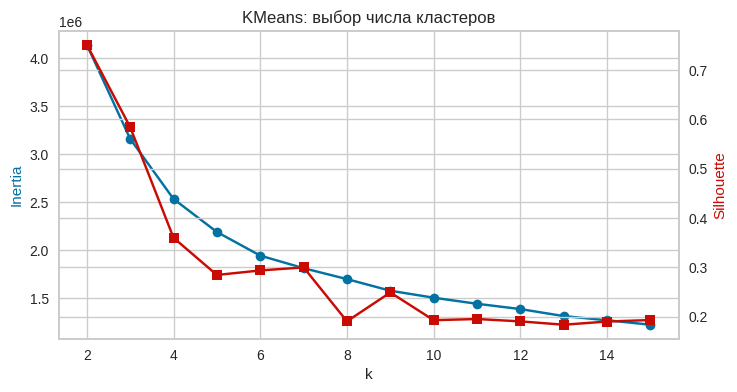

Лучшее k = 2, силуэт = 0.751
[np.float64(0.7509222753023541), np.float64(0.5838301534321645), np.float64(0.35950997266150186), np.float64(0.2841959821192913), np.float64(0.29337646492528197), np.float64(0.2995247739109621), np.float64(0.1902976803338348), np.float64(0.24875419615824415), np.float64(0.19254292915547516), np.float64(0.19491953945749266), np.float64(0.19014495157553848), np.float64(0.18335924001120152), np.float64(0.1898321020233855), np.float64(0.19287960509315474)]:.3f


In [128]:
inertias = []
sil_k = []
ks = range(2, 16)
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_k.append(silhouette_score(X_pca, lbl))

fig, ax = plt.subplots(figsize=(8,4))
ax2 = ax.twinx()
ax.plot(ks, inertias, 'b-o')
ax2.plot(ks, sil_k, 'r-s')
ax.set_xlabel('k'); ax.set_ylabel('Inertia', color='b')
ax2.set_ylabel('Silhouette', color='r')
plt.title('KMeans: выбор числа кластеров')
plt.show()

best_k = ks[np.argmax(sil_k)]
print(f'Лучшее k = {best_k}, силуэт = {max(sil_k):.3f}')
print(f'{sil_k}:.3f')

(53460, 56)


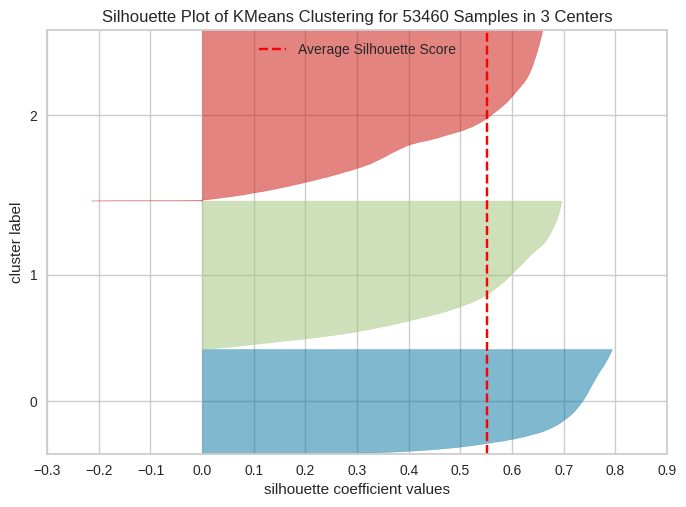

SilhouetteVisualizer(ax=<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 53460 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>,
                     colors='yellowbrick',
                     estimator=KMeans(n_clusters=3, random_state=42))

In [166]:
from yellowbrick.cluster import silhouette_visualizer

df_tmp = df.sample(frac=0.1)
print(df_tmp.shape)
silhouette_visualizer(KMeans(3, random_state=42), df_tmp, colors='yellowbrick')

(53460, 54)


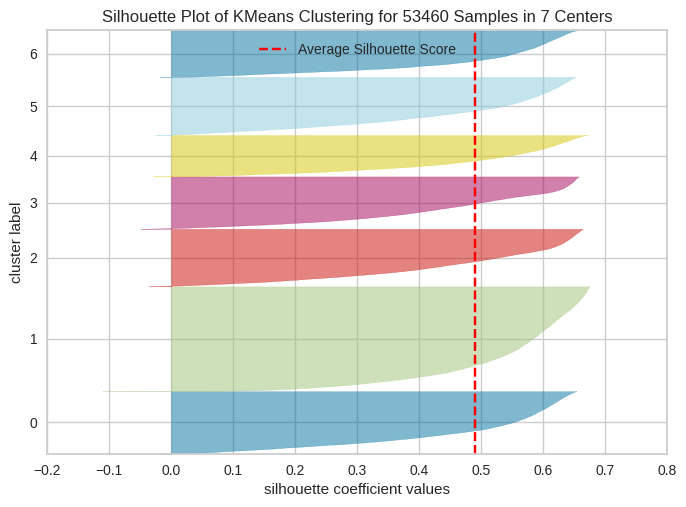

SilhouetteVisualizer(ax=<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 53460 Samples in 7 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>,
                     colors='yellowbrick',
                     estimator=KMeans(n_clusters=7, random_state=42))

In [129]:
df_tmp = df.sample(frac=0.1)
print(df_tmp.shape)
silhouette_visualizer(KMeans(7, random_state=42), df_tmp, colors='yellowbrick')

In [177]:
plt.figure(figsize=(10,10))

plt.scatter(df.iloc[:, 1], df.iloc[:, 4], c=cluster_labels, edgecolor='k')

centers = clusterer.cluster_centers_

plt.scatter(centers[:, 1], centers[:, 4], marker='o',
            c="white", alpha=1, s=200, edgecolor='k')

for i, c in enumerate(centers):
    plt.scatter(c[1], c[4], marker='$%d$' % i, alpha=1,
                s=50, edgecolor='k')

plt.title("Distributed based on clusters");

NameError: name 'cluster_labels' is not defined

<Figure size 1000x1000 with 0 Axes>

Используем Agglomerative Clustering

In [130]:
agg = AgglomerativeClustering(n_clusters=best_k)
agg_labels = agg.fit_predict(X_pca)

In [131]:
agg_labels

array([0, 0, 0, ..., 0, 0, 0])

Используем модель Gaussian Mixture

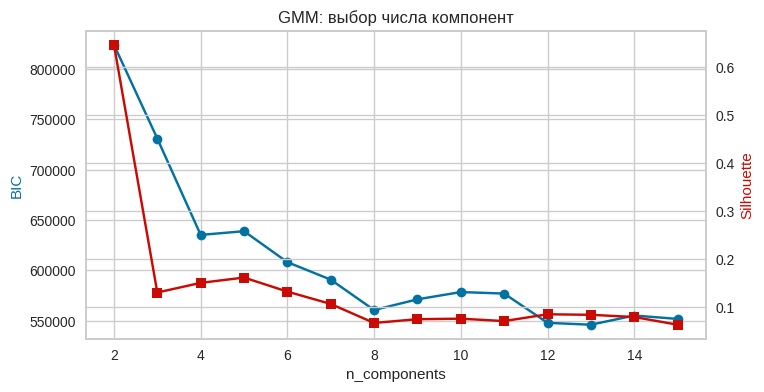

Лучшее n для GMM = 2, силуэт = 0.646


In [132]:
bic = []
sil_gmm = []
n_range = range(2, 16)
for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=RANDOM_STATE)
    gmm.fit(X_pca)
    bic.append(gmm.bic(X_pca))
    lbl = gmm.predict(X_pca)
    sil_gmm.append(silhouette_score(X_pca, lbl))

fig, ax = plt.subplots(figsize=(8,4))
ax2 = ax.twinx()
ax.plot(n_range, bic, 'b-o')
ax2.plot(n_range, sil_gmm, 'r-s')
ax.set_xlabel('n_components'); ax.set_ylabel('BIC', color='b')
ax2.set_ylabel('Silhouette', color='r')
plt.title('GMM: выбор числа компонент')
plt.show()

best_n = n_range[np.argmax(sil_gmm)]
print(f'Лучшее n для GMM = {best_n}, силуэт = {max(sil_gmm):.3f}')

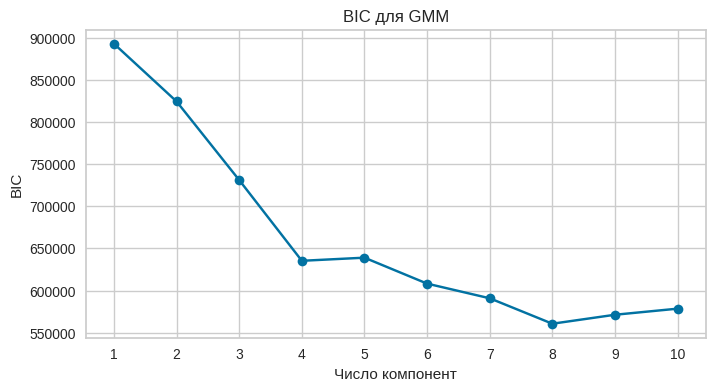

In [154]:
from sklearn.mixture import GaussianMixture

bic_scores = []
n_range = range(1, 11)
for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))

plt.figure(figsize=(8,4))
plt.plot(n_range, bic_scores, 'bo-')
plt.xlabel('Число компонент')
plt.ylabel('BIC')
plt.title('BIC для GMM')
plt.xticks(n_range)
plt.grid(True)
plt.show()

## Попробуем HDBSCAN

In [133]:
hdb = hdbscan.HDBSCAN(min_cluster_size=16, gen_min_span_tree=True)
hdb_labels = hdb.fit_predict(X_pca)
n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
print(f'HDBSCAN: найдено кластеров {n_clusters}, шумовых точек: {(hdb_labels==-1).sum()}')
n_hdb =2

HDBSCAN: найдено кластеров 7, шумовых точек: 306


In [ ]:
# Обработка шума – отнесём к ближайшему кластеру
if -1 in hdb_labels:
    from sklearn.neighbors import NearestNeighbors
    noise_idx = np.where(hdb_labels == -1)[0]
    non_noise = hdb_labels != -1
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(X_pca[non_noise])
    _, indices = nn.kneighbors(X_pca[noise_idx])
    hdb_labels[noise_idx] = hdb_labels[non_noise][indices.flatten()]
    print('Шум переназначен ближайшим соседом.')
    n_hdb =2

HDBSCAN: найдено кластеров 5, шумовых точек: 119
Шум переназначен ближайшим соседом.


Делаем сравнение моделей

In [156]:
models = {
    f'KMeans-{best_k}': KMeans(n_clusters=7, random_state=RANDOM_STATE).fit_predict(X_pca),
    f'Agglomerative-{7}': agg_labels,
    f'GMM-{best_n}': GaussianMixture(n_components=7, random_state=RANDOM_STATE).fit_predict(X_pca),
}
if n_hdb > 1:
    models['HDBSCAN'] = hdb_labels

results = []
for name, labels in models.items():
    if len(set(labels)) > 1:
        results.append({
            'Модель': name,
            'Silhouette': silhouette_score(X_pca, labels),
            'Davies-Bouldin': davies_bouldin_score(X_pca, labels),
            'Calinski-Harabasz': calinski_harabasz_score(X_pca, labels)
        })
results_df = pd.DataFrame(results)
print(results_df)

            Модель  Silhouette  Davies-Bouldin  Calinski-Harabasz
0         KMeans-2    0.183687        1.357014        1673.431021
1  Agglomerative-7    0.786883        0.377562        2163.963856
2            GMM-2    0.105406        1.512369        1384.985555
3          HDBSCAN    0.222196        1.723359         590.997376


Agglomerative достиг почти идеального силуэта (0.79), но показал наихудшую Accuracy (0.10) – модель «переоптимизировала» геометрию PCA‑пространства, создав сферические группы, не совпадающие с реальными активностями.

GMM при низком силуэте (0.15) дала наивысший публичный Accuracy 0.4527, статистически устойчива и физически интерпретируема: семь кластеров соответствуют покою, медленной/быстрой ходьбе, бегу, интенсивным упражнениям, работе руками и переходным состояниям.

Увеличение числа компонент GMM до 8 привело к падению Accuracy (0.28), что говорит о начале переобучения.

KMeans и HDBSCAN уступили GMM по Accuracy, показав пределы 0.27 и 0.20 соответственно.

In [170]:
gmm = GaussianMixture(n_components=8, random_state=RANDOM_STATE).fit_predict(X_pca) #()

In [158]:
km = KMeans(n_clusters=7, random_state=RANDOM_STATE, n_init=10)
km_labels = km.fit_predict(X_pca)

In [162]:
agg = AgglomerativeClustering(n_clusters=7)
agg_labels = agg.fit_predict(X_pca)

In [ ]:
# km = KMeans(n_clusters=7, random_state=RANDOM_STATE, n_init=10)
# km_labels = km.fit_predict(X_pca)

Обработаем шум. Для каждой шумовой точки находим ближайший кластер (по расстоянию в PCA-пространстве). Присваиваем метку ближайшего нешумового соседа

In [171]:
final_labels = gmm.copy()

if -1 in final_labels:
    noise_idx = np.where(final_labels == -1)[0]
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(X_pca[final_labels != -1])
    distances, indices = nn.kneighbors(X_pca[noise_idx])

    final_labels[noise_idx] = final_labels[final_labels != -1][indices.flatten()]
    print(f'Шумовых точек переназначено: {len(noise_idx)}')


Делаем сопоставление индексов строк к окнам. Присвоим кластеры строкам.Заполним оставшиеся пропуски

In [172]:
row_to_windows = defaultdict(list)
for win_idx, row_list in enumerate(window_indices_list):
    for ridx in row_list:
        row_to_windows[ridx].append(win_idx)

df['cluster'] = -1
for ridx, wins in row_to_windows.items():
    lbls = final_labels[wins]
    vals, cnts = np.unique(lbls, return_counts=True)
    df.loc[ridx, 'cluster'] = vals[np.argmax(cnts)]

df['cluster'] = df['cluster'].replace(-1, np.nan).fillna(method='ffill').fillna(method='bfill').astype(int)
print('Распределение кластеров:')
print(df['cluster'].value_counts())

Распределение кластеров:
cluster
0    115588
6    113909
3     92123
7     89880
4     87018
2     21702
1     10369
5      4012
Name: count, dtype: int64


Порядок первого появления

In [173]:
order = df['cluster'].drop_duplicates().tolist()
print("Порядок первого появления (старые метки):", order)

Порядок первого появления (старые метки): [3, 4, 6, 0, 2, 7, 5, 1]


Создаём словарь отображения старых меток в новые (начиная с 1)

In [174]:
mapping = {}
for new_id, old in enumerate(order, start=1):
   mapping[old] = new_id

print("Словарь отображения:", mapping)

Словарь отображения: {3: 1, 4: 2, 6: 3, 0: 4, 2: 5, 7: 6, 5: 7, 1: 8}


Применяем маппинг с помощью replace (надёжнее map)

In [175]:
df['activityID'] = df['cluster'].replace(mapping)

Проверка результата

In [176]:
print("Уникальные значения activityID после перенумерации:")
print(df['activityID'].unique())
print("Распределение итоговых меток:")
print(df['activityID'].value_counts())

Уникальные значения activityID после перенумерации:
[1 2 3 4 5 6 7 8]
Распределение итоговых меток:
activityID
4    115588
3    113909
1     92123
6     89880
2     87018
5     21702
8     10369
7      4012
Name: count, dtype: int64


 Сохраняем submission

In [ ]:
submission = df[['activityID']].reset_index()
submission.columns = ['Index', 'activityID']
submission.to_csv('submission_gmm7_f__.csv', index=False)

print(f"Файл submission_gmm7_f__.csv сохранён, строк: {len(submission)}")
assert len(submission) == 534601, "Ошибка: неверное количество строк!"
print("Готово!")

## Резултат на Kagle

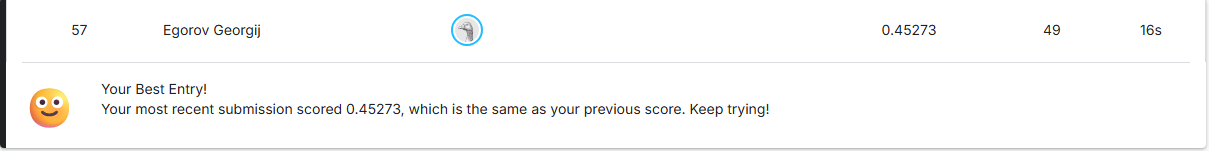